(gettingstarted)=
# Getting started

## Introduction to network control

Classically, many neuroimaging studies have been interested in how the brain can be guided toward specific, diverse
patterns of neural activity. Network control theory (NCT) is a powerful tool from physical and engineering sciences
that can provide insight into these questions. NCT provides a specific, dynamical equation that defines how the
activity of the brain will spread along white matter connections in response to some input. Important to these tools
is the definition of the system (here, the brain) as a network, with nodes (brain regions) connected by edges. This
network is stored in the adjacency matrix, $\mathbf{A}$. In neuroimaging, much of the application of NCT is
divided into two categories: *controllability statistics* and *control energies*. Controllability statistics are
properties of a structural brain network, or node in the network, that summarise information about control to many,
nonspecific activity states. Control energies, on the other hand, provide quantification of how easily the network
can transition between two specific activity states. For a more detailed introduction, see {ref}`theory`.

`nctpy` is a Python toolbox that implements commonly used analyses from NCT. In this overview, we will walk
through some of the basic functions, and important considerations for using NCT. The steps below will help you to get
started. If you haven't done so yet, we recommend that you install the package ({ref}`installation_setup`) so you can
follow along with the examples. This page also uses matplotlib and seaborn, which `pip install "nctpy[plot]"`
installs.

## Defining a dynamical system

We start by initializing a random adjacency matrix ($\mathbf{A}$) that will serve as a proxy for our structural
connectivity. The matrix $\mathbf{A}$ defines the possible paths of activity spread for our dynamical system.

In [1]:
import numpy as np
# initialize A matrix
np.random.seed(42)  # for reproducibility
n_nodes = 5
A = np.random.rand(n_nodes, n_nodes)
print(A)

[[0.37454012 0.95071431 0.73199394 0.59865848 0.15601864]
 [0.15599452 0.05808361 0.86617615 0.60111501 0.70807258]
 [0.02058449 0.96990985 0.83244264 0.21233911 0.18182497]
 [0.18340451 0.30424224 0.52475643 0.43194502 0.29122914]
 [0.61185289 0.13949386 0.29214465 0.36636184 0.45606998]]


In `nctpy`, the dynamics of the system will evolve according to one of two definitions. The first is a discrete-time
system that follows this equation:

$$
\mathbf{x}(t+1) = A\mathbf{x}(t) + B\mathbf{u}(t).
$$

The second is a continuous-time system that follows this equation:

$$
\frac{\mathrm{d}}{\mathrm{d}t} \mathbf{x}(t) = A\mathbf{x}(t) + B\mathbf{u}(t).
$$

In both equations, $\mathbf{x}$ is the state (or regional neural activity) of the system over time,
$\mathbf{u}$ is the input to the system, and $B$ defines which nodes receive input.

Before applying one of the above models, most work will first normalize $\mathbf{A}$ to be stable. In response to
adding a single unit of input, the activity in a stable matrix will spread but eventually die down, and the system
will reach a stable state. By contrast, an unstable system will exhibit states that continue growing forever.
Practically, this normalization is done differently depending on whether we analyze a discrete-time or a
continuous-time system. For discrete-time systems, all eigenvalues must be less than 1 in magnitude for the system to
be stable, and for continuous-time systems all eigenvalues must have negative real parts. Unless otherwise noted, the
functions of `nctpy` will work across both time systems. Here, we will define our system to be in discrete time,
which can be achieved using the {func}`nctpy.utils.matrix_normalization` function:

In [2]:
from nctpy.utils import matrix_normalization
system = 'discrete'
A_norm = matrix_normalization(A=A, c=1, system=system)
print(A_norm)

[[0.11828952 0.30026034 0.23118275 0.18907194 0.04927475]
 [0.04926713 0.01834432 0.27356099 0.18984778 0.22362776]
 [0.00650112 0.30632279 0.26290707 0.06706222 0.05742506]
 [0.05792392 0.09608762 0.16573175 0.13641949 0.09197775]
 [0.19323908 0.04405579 0.09226689 0.11570661 0.14403878]]


We can visualize the behavior of a stable and unstable matrix by simulating the system's response to a small amount
of input. These simulations can be run using the {func}`nctpy.energies.sim_state_eq` function. First, let's visualize
the stable matrix we created above, `A_norm`:

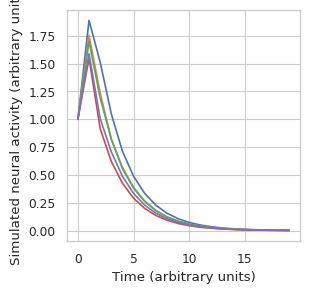

In [3]:
from nctpy.energies import sim_state_eq
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid', context='paper', font_scale=1)

T = 20  # time horizon
U = np.zeros((n_nodes, T))  # the input to the system
U[:, 0] = 1  # impulse, 1 input at the first time point delivered to all nodes
B = np.eye(n_nodes)  # uniform full control set
x0 = np.ones((n_nodes, 1))  # initial state, all nodes set to 1 unit of neural activity
x = sim_state_eq(A_norm=A_norm, B=B, x0=x0, U=U, system=system)

# plot
f, ax = plt.subplots(1, 1, figsize=(3, 3))
ax.plot(x.T)
ax.set_ylabel('Simulated neural activity (arbitrary units)')
ax.set_xlabel('Time (arbitrary units)')
plt.show()

The above figure shows that our system nodes all started with 1 unit of activity. Then, an impulse was delivered which
increased their activity by different amounts. This happened because of the connectivity between nodes. Finally,
following the impulse, all activity decayed to 0 over time. Next, let's see what happens when we use the unstable
matrix, `A`:

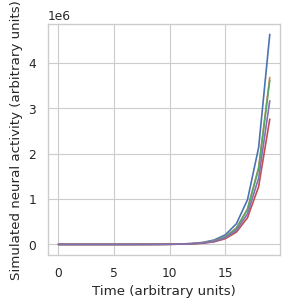

In [4]:
# unstable A
x = sim_state_eq(A_norm=A, B=B, x0=x0, U=U, system=system)

# plot
f, ax = plt.subplots(1, 1, figsize=(3, 3))
ax.plot(x.T)
ax.set_ylabel('Simulated neural activity (arbitrary units)')
ax.set_xlabel('Time (arbitrary units)')
plt.show()

In the unstable case, we can see that activity has exploded over time.

## Calculating controllability statistics

Now that we have a stable matrix, we're ready to calculate some NCT metrics. The first metric included
in `nctpy` is *average controllability*. Average controllability measures the impulse response of the
system, and can be thought of as an indicator of a node's general capacity to control dynamics. Average controllability
can be calculated using {func}`nctpy.metrics.ave_control`:

In [5]:
from nctpy.metrics import ave_control
ac = ave_control(A_norm=A_norm, system=system)
print(ac)

[1.08025104 1.31106261 1.45318469 1.18821797 1.14836708]


Each node gets one value; the higher it is, the more the system responds to input delivered at that node.

## Calculating control energies

Now, let's say instead that we want to know how well our system can transition between two specific neural states. To
achieve this, we can calculate the amount of *control energy* that would need to be input into our system to
transition it between an initial state ($x_0$) and a target state ($x_f$). This is done using
{func}`nctpy.energies.get_control_inputs` and {func}`nctpy.energies.integrate_u`. For the sake of demonstration,
let's switch to a continuous-time system here. Note, `ave_control`, `get_control_inputs`, and `integrate_u` can all
be used for both discrete-time and continuous-time systems:

In [6]:
system = 'continuous'
A_norm = matrix_normalization(A=A, c=1, system=system)
print(A_norm)

[[-0.88171048  0.30026034  0.23118275  0.18907194  0.04927475]
 [ 0.04926713 -0.98165568  0.27356099  0.18984778  0.22362776]
 [ 0.00650112  0.30632279 -0.73709293  0.06706222  0.05742506]
 [ 0.05792392  0.09608762  0.16573175 -0.86358051  0.09197775]
 [ 0.19323908  0.04405579  0.09226689  0.11570661 -0.85596122]]


In [7]:
from nctpy.energies import get_control_inputs, integrate_u

# define initial and target states as random patterns of activity
np.random.seed(42)  # for reproducibility
x0 = np.random.rand(n_nodes, 1)  # initial state
xf = np.random.rand(n_nodes, 1)  # target state

# set parameters
T = 1  # time horizon
rho = 1  # mixing parameter for state trajectory constraint
S = np.eye(n_nodes)  # nodes in state trajectory to be constrained

# get the state trajectory (x) and the control inputs (u)
x, u, n_err = get_control_inputs(A_norm=A_norm, T=T, B=B, x0=x0, xf=xf, system=system, rho=rho, S=S)

`get_control_inputs` outputs the neural activity of the system (`x`, state trajectory), the control signals that
drove the system to transition between the initial and target states (`u`), and a pair of numerical errors
(`n_err`). Let's unpack all this!

To complete the state transition, `get_control_inputs` utilizes a cost function that constrains both the magnitude
of the control signals (`u`) as well as the magnitude of the state trajectory (`x`). That is, we are primarily
trying to find the control signals that achieve a desired state transition with the lowest amount of input, while also
constraining the level of neural activity in the state trajectory; we don't want wild fluctuations in neural
activity! The input parameter `rho` allows researchers to tune the mixture of these two costs while
finding the control signals. Specifically, `rho=1` places equal cost over the magnitude of the control signals and
the state trajectory. Reducing `rho` below 1 increases the extent to which the state trajectory adds to the cost
function alongside the control signals. Conversely, increasing `rho` beyond 1 reduces the state trajectory
contribution, thus increasing the relative prioritization of the control signals. `rho` must be positive. Lastly,
`S` takes in an $N \times N$ matrix whose diagonal elements define which nodes' activity will be constrained in the
state trajectory. In summary, `S` designates which nodes' neural activity will be constrained while `rho`
determines by how much (relative to the control signals). Here, by setting `rho=1` and `S=np.eye(n_nodes)`, we are
implementing what we refer to as *optimal control*. If `S` is set to an $N \times N$ matrix of zeros, then the state
trajectory is completely unconstrained; we refer to this setup as *minimum control*. In this case, the value of `rho`
does not affect the result.

Next, let's consider those numerical errors. The first error is the *inversion error*, which measures the
conditioning of the optimization problem. If this error is small, then solving for the control signals was
well-conditioned. The second error is the *reconstruction error*, which is a measure of the distance between the
target state (`xf`) and the state trajectory at time `T`. If this error is small, then the state
transition completed successfully; that is, the neural activity at the end of the simulation was equivalent to the
neural activity encoded by `xf`. We consider errors $< 1 \times 10^{-8}$ as adequately small:

In [8]:
# print errors
thr = 1e-8

# the first numerical error corresponds to the inversion error
print('inversion error = {:.2E} (<{:.2E}={:})'
      .format(n_err[0], thr, n_err[0] < thr))

# the second numerical error corresponds to the reconstruction error
print('reconstruction error = {:.2E} (<{:.2E}={:})'
      .format(n_err[1], thr, n_err[1] < thr))

inversion error = 2.31E-16 (<1.00E-08=True)
reconstruction error = 5.17E-14 (<1.00E-08=True)


Now that we've unpacked all that, let's plot the state trajectory (`x`) and the control signals (`u`) to see what
they're doing:

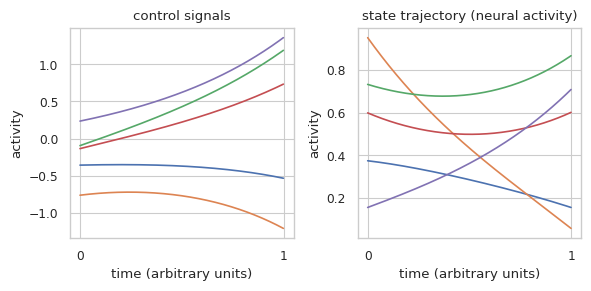

In [9]:
# plot x and u
f, ax = plt.subplots(1, 2, figsize=(6, 3))
# plot control signals for initial state
ax[0].plot(u)
ax[0].set_title('control signals')

# plot state trajectory for initial state
ax[1].plot(x)
ax[1].set_title('state trajectory (neural activity)')

for cax in ax.reshape(-1):
    cax.set_ylabel("activity")
    cax.set_xlabel("time (arbitrary units)")
    cax.set_xticks([0, x.shape[0]])
    cax.set_xticklabels([0, T])

f.tight_layout()
plt.show()

Finally, we'll integrate `u` to compute *control energy*:

In [10]:
# integrate control inputs to get control energy
node_energy = integrate_u(u)
print('node energy =', node_energy)

# summarize nodal energy to get control energy
energy = np.sum(node_energy)
print('energy = {:.2F}'.format(np.round(energy, 2)))

node energy = [159.35334645 728.32771143 349.67802113 120.56428349 563.2983561 ]
energy = 1921.22


The last line is the *control energy* of our state transition.

That concludes the *getting started* section.